## Instalar liberías necesarias

In [ ]:
!pip install ultralytics roboflow

## Descomprimir archivo con conjunto de datos del roboflow


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="QYcAq5SY5FQozQlkU5Vy")
project = rf.workspace("workspace-hoc3o").project("bone-detection-pro")
version = project.version(7)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## Entrenar modelo

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv
import torch
import os

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponible. Usando:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU disponible. Usando CPU.")

GPU disponible. Usando: Tesla T4


In [ ]:
# Cargar un modelo YOLO26n preentrenado
model = YOLO('/content/yolo26n.pt')

# RECORDAR UTILIZAR LA GPU CON device=0
train_results = model.train(
    data="/content/Bone-Detection-PRO+-6/data.yaml",   # Ruta al archivo de configuración del conjunto de datos
    epochs=100,          # Número de épocas de entrenamiento
    imgsz=1024,          # Tamaño de las imágenes durante el entrenamiento
    device=0,       # Usar GPU si está disponible
)

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bone-Detection-PRO+-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimi

El modelo de detección fue sometido a un proceso de entrenamiento de 100 épocas, utilizando una resolución de entrada de 1024x1024 y el optimizador Adam. El entrenamiento se ejecutó en una GPU Tesla T4, completando el proceso en un tiempo de 66 minutos.

Durante la fase de entrenamiento, la evolución de las funciones de pérdida reflejó un aprendizaje estable. La cls loss experimentó una reducción desde 12.45 en la etapa inicial hasta 0.37 en la última época, indicando una sólida capacidad adquirida para discriminar entre las dos clases objetivo ("Conminuta" y "Simple"). Simultáneamente, las métricas asociadas a la localización espacial de las detecciones, como box loss y DFL Loss, disminuyeron de manera sostenida. Estas pasaron de 1.98 a 0.78 y de 0.017 a 0.007 respectivamente, lo que comprueba un refinamiento progresivo en el ajuste de las coordenadas de las cajas delimitadoras a medida que avanzaban las iteraciones.

En la evaluación final sobre el conjunto de validación, el modelo registró una Precisión general del 61.9% y un Recall del 52.5%. La métrica principal de rendimiento, el mAP50, se situó en un 49.2% global. Al desglosar este resultado por clases, se observa que el algoritmo identifica con mayor facilidad las fracturas de tipo "Simple", logrando un mAP50 de 55.5%, en comparación con un 42.9% obtenido para las fracturas de tipo "Conminuta". Esta diferencia es esperable dada la naturaleza fragmentada y más compleja de las lesiones conminutas.  Por último, el indicador mAP50-95, alcanzó un 20.9% general. Este valor evidencia que, si bien el sistema logra localizar la región general de las lesiones y clasificarlas de manera competente, la delimitación de las fracturas sigue siendo un desafío y un comportamiento habitual en el procesamiento de imágenes de este tipo debido a la presencia de bordes óseos superpuestos o difusos.


In [ ]:
# Evaluar el rendimiento del modelo en el conjunto de validación
model = YOLO('/content/runs/detect/train-3/weights/best.pt')

metrics = model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 514.5±103.5 MB/s, size: 28.1 KB)
val: Scanning /content/Bone-Detection-PRO+-6/valid/labels.cache... 170 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170 39.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.5s/it 27.2s
                   all        170        306      0.619      0.525      0.492      0.209
             Conminuta         82        154      0.582      0.497      0.429      0.193
                Simple         84        152      0.656      0.553      0.555      0.226
Speed: 17.2ms preprocess, 15.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-3


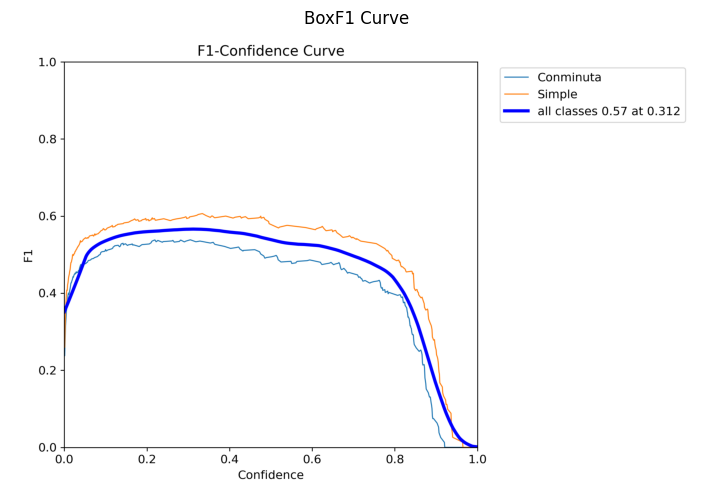

In [ ]:
image_path = '/content/runs/detect/val-3/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

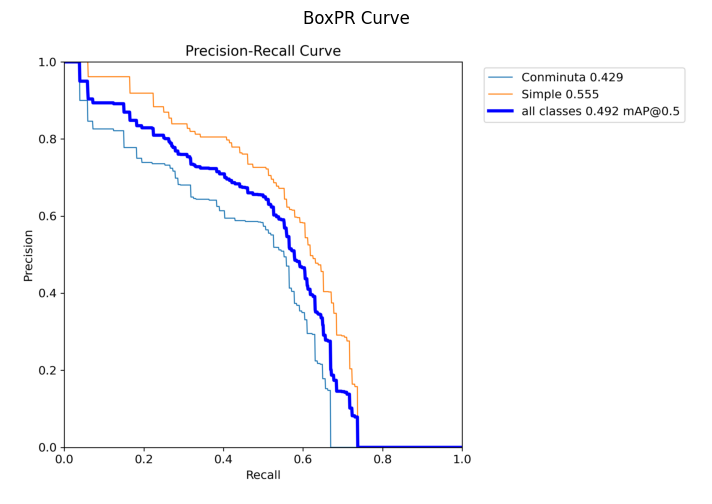

In [ ]:
image_path = '/content/runs/detect/val-3/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxPR Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

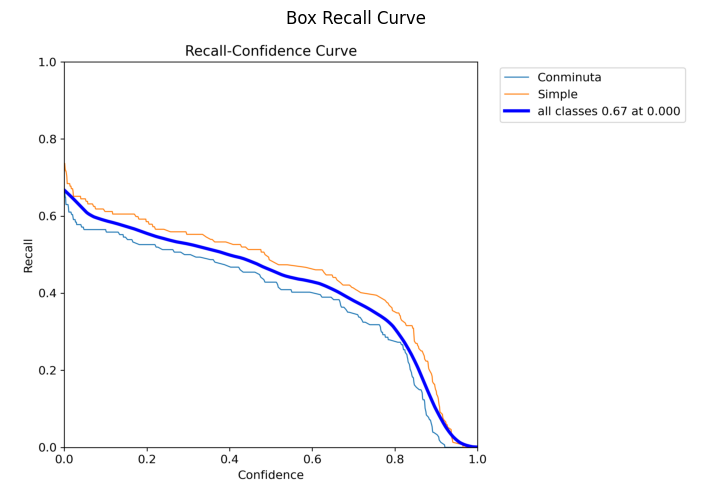

In [ ]:
image_path = '/content/runs/detect/val-3/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

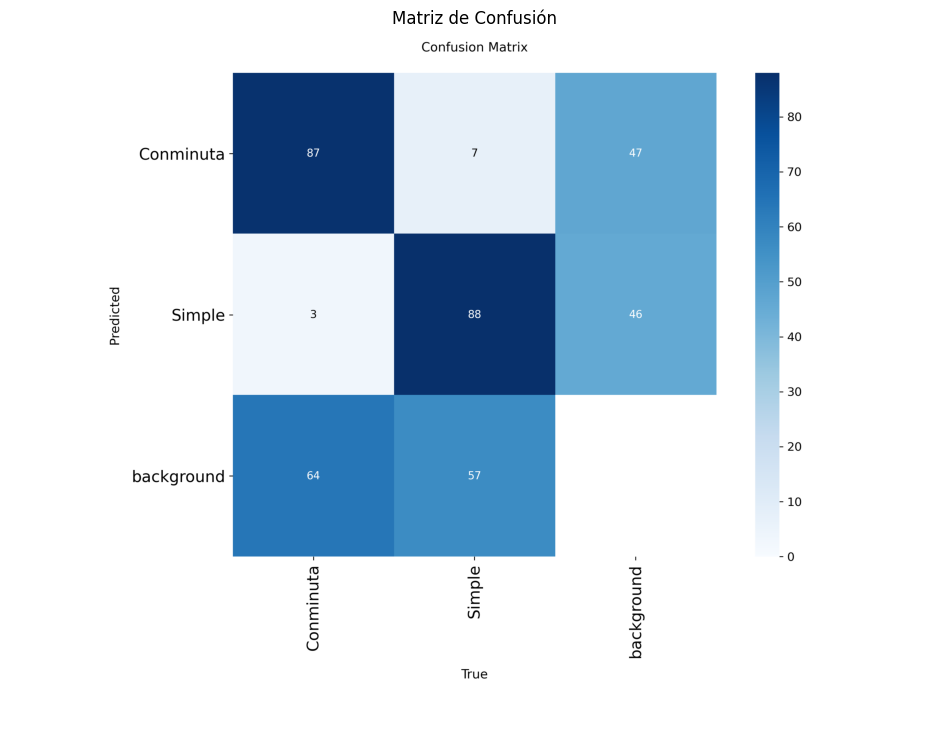

In [ ]:
image_path = '/content/runs/detect/val-3/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

# Predicciones YOLO + OpenCV


image 1/1 /content/Fotos/Conminuta.jpg: 704x1024 2 Conminutas, 77.0ms
Speed: 4.8ms preprocess, 77.0ms inference, 0.5ms postprocess per image at shape (1, 3, 704, 1024)
Bounding Box: tensor([[ 43.4161, 107.5106,  94.3110, 170.2970]], device='cuda:0'), Confidence: tensor([0.8812], device='cuda:0'), Class: Conminuta
Bounding Box: tensor([[181.6689, 111.1319, 227.4976, 171.3852]], device='cuda:0'), Confidence: tensor([0.8677], device='cuda:0'), Class: Conminuta


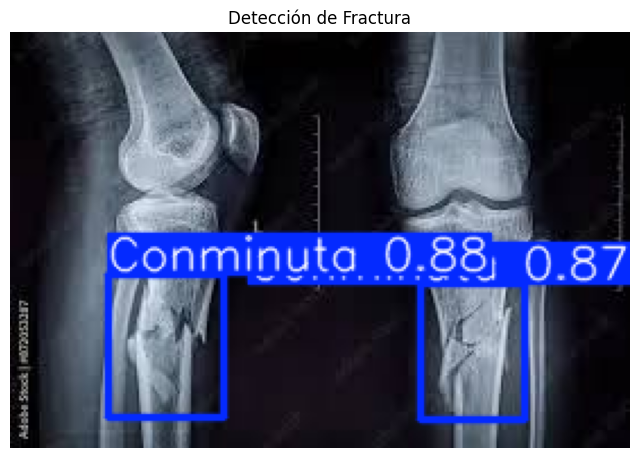

In [ ]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Ruta de la imagen
image_path = '/content/Fotos/Conminuta.jpg'

# Realizar la detección
results = model(image_path)

# print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de Fractura')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)

Al evaluar esta radiografía, el modelo logró identificar sin problemas dos fracturas conminutas, acertando con un nivel de confianza bastante alto del 88% y 87%. Lo más destacable es que los recuadros logran enmarcar de forma muy precisa los fragmentos óseos en ambas proyecciones de la pierna.


image 1/1 /content/Fotos/Simple.jpg: 1024x448 1 Conminuta, 12.9ms
Speed: 3.3ms preprocess, 12.9ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 448)
Bounding Box: tensor([[125.2558, 387.4857, 203.6035, 515.9912]], device='cuda:0'), Confidence: tensor([0.5777], device='cuda:0'), Class: Conminuta


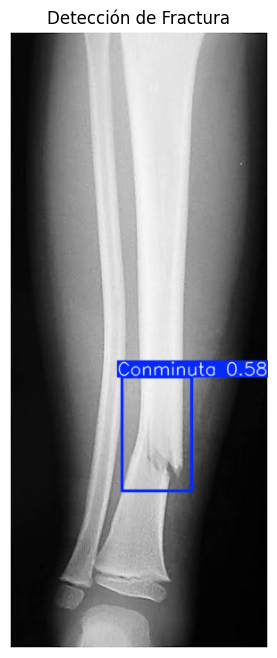

In [ ]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Ruta de la imagen
image_path = '/content/Fotos/Simple.jpg'

# Realizar la detección
results = model(image_path)

# print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de Fractura')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen_error.jpg', im_array)

En este caso vemos un claro ejemplo de un error de clasificación por parte del algoritmo. Aunque logró localizar la zona del daño óseo, se equivocó al etiquetarla como "conminuta", mostrando además un nivel de confianza bastante bajo, de apenas un 58%. Esta confusión seguramente ocurrió porque la forma irregular del trazo o las sombras superpuestas en la radiografía hicieron dudar al modelo, llevándolo a interpretar más fragmentos de los que realmente existen.


image 1/1 /content/Fotos/Conminuta2.png: 1024x800 (no detections), 60.2ms
Speed: 4.8ms preprocess, 60.2ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 800)


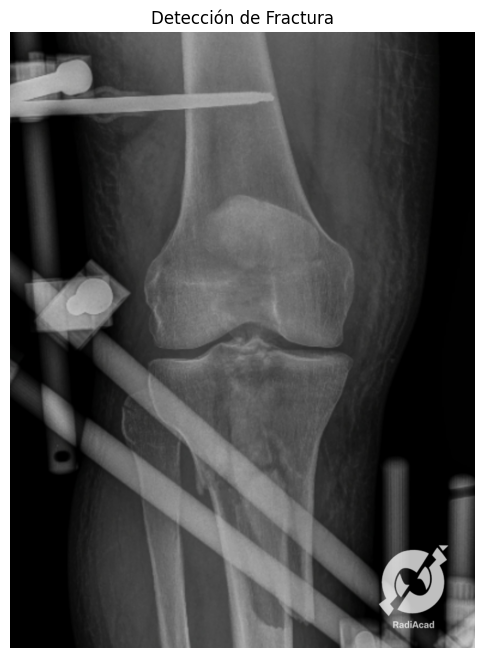

In [ ]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Ruta de la imagen
image_path = '/content/Fotos/Conminuta2.png'

# Realizar la detección
results = model(image_path)

# print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de Fractura')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen_error.jpg', im_array)

Aquí estamos viendo un claro "falso negativo", el modelo falló por completo al no detectar la lesión. La razón principal de esta omisión es casi con total seguridad la presencia del fijador metálico que cruza toda la pierna. Este aparato oculta en parte los bordes del hueso y alteran los contrastes y patrones visuales normales. Durante el proceso de entrenamiento el modelo no fue vio la suficiente cantidad de imagenes de casos con estos objetos, esto hizo que se confundiera y pasara por alto una fractura conminuta.


image 1/1 /content/Fotos/Conminuta4.jpg: 1024x1024 1 Conminuta, 14.8ms
Speed: 6.4ms preprocess, 14.8ms inference, 0.4ms postprocess per image at shape (1, 3, 1024, 1024)
Bounding Box: tensor([[ 23.4036, 229.6324, 162.9206, 429.8926]], device='cuda:0'), Confidence: tensor([0.7502], device='cuda:0'), Class: Conminuta


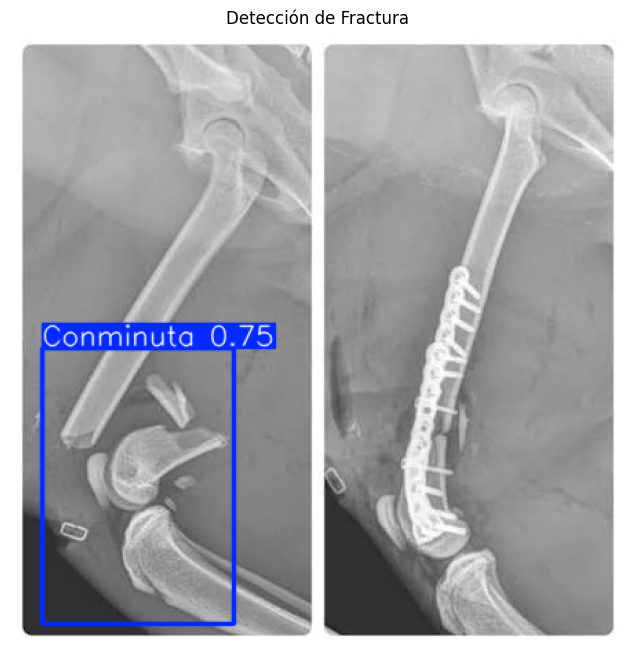

In [ ]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train-3/weights/best.pt')

# Ruta de la imagen
image_path = '/content/Fotos/Conminuta4.jpg'

# Realizar la detección
results = model(image_path)

# print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de Fractura')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen_error.jpg', im_array)

En este par de radiografías vemos una situación bastante interesante. En la parte de la izquierda, el modelo detecta sin problemas la fractura conminuta con un 75% de seguridad, encerrando bastante bien la zona de los fragmentos sueltos. Sin embargo, en la parte de la derecha no detecta nada. Esto tiene mucho sentido, ya que se trata de la misma lesión pero ya operada y fijada con una placa y varios tornillos. Al estar el hueso alineado y alterado por los implantes metálicos, el algoritmo simplemente ya no reconoce el patrón visual de una fractura activa o, al igual que en el caso anterior, los propios metales lo confunden y anulan su capacidad de detección.